# FinRise Risk Management Project - Part 3: Nano Lending Portfolio Credit Risk Modelling

**Course:** Financial Risk Analytics  
**Team:** Umer Raza, Syed Yahya Tariq  

## Overview
The management has highlighted that the main risk driver for FinRise remains its nano-lending operations. The company has seen rising defaults, especially among first-time and gig-economy borrowers, and currently lacks a systematic model to predict borrower default risk.

This notebook develops a logistic regression model to estimate the Probability of Default (PD), evaluates model performance, and identifies the optimal PD threshold that maximizes net financial impact.



## Task 1: Data Exploration and Preparation

In this task, the dataset is imported and checked for missing values, data types, and outliers.  
The target variable for this model is **defaulted**, where:

- **1 = default**
- **0 = repaid**

The purpose of this step is to clean the data and make it ready for modelling.

In [59]:
# Importing Required Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    roc_curve,
    roc_auc_score,
    classification_report
)

In [60]:
# Load dataset
df = pd.read_csv("../data/FinRise_loan_data.csv")
print(df.head())

   loan_amount  loan_maturity_days  interest_rate   borrower_type  age  \
0  25476.99907                  71       0.279569      Freelancer   25   
1  21032.14989                  85       0.271865  Small Merchant   49   
2  26533.81977                  46       0.276727      Freelancer   20   
3  32661.20899                  60       0.293419      Freelancer   57   
4  20360.92638                  82       0.316718  Small Merchant   44   

   credit_score  employment_years  defaulted  
0           567                 7          0  
1           412                11          0  
2           704                14          0  
3           701                 3          0  
4           535                 7          0  


In [61]:
# Basic information about dataset
print("Shape:", df.shape)
print("\nColumns:", df.columns)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

Shape: (10000, 8)

Columns: Index(['loan_amount', 'loan_maturity_days', 'interest_rate', 'borrower_type',
       'age', 'credit_score', 'employment_years', 'defaulted'],
      dtype='object')

Data Types:
loan_amount           float64
loan_maturity_days      int64
interest_rate         float64
borrower_type          object
age                     int64
credit_score            int64
employment_years        int64
defaulted               int64
dtype: object

Missing Values:
loan_amount           0
loan_maturity_days    0
interest_rate         0
borrower_type         0
age                   0
credit_score          0
employment_years      0
defaulted             0
dtype: int64


In [62]:
df['defaulted'].value_counts()

defaulted
0    9497
1     503
Name: count, dtype: int64

In [48]:
# Summary statistics
print(df.describe(include="all"))
df.info()

         loan_amount  loan_maturity_days  interest_rate borrower_type  \
count   10000.000000        10000.000000   10000.000000         10000   
unique           NaN                 NaN            NaN             3   
top              NaN                 NaN            NaN    Freelancer   
freq             NaN                 NaN            NaN          4012   
mean    22103.854502           59.973200       0.280826           NaN   
std      6726.476836           17.652967       0.018827           NaN   
min     10000.000000           30.000000       0.250000           NaN   
25%     17291.866292           45.000000       0.266629           NaN   
50%     21981.835170           60.000000       0.280216           NaN   
75%     26697.566212           75.000000       0.293935           NaN   
max     40806.116093           90.000000       0.334895           NaN   

                 age  credit_score  employment_years  defaulted  
count   10000.000000   10000.00000      10000.000000    1

In [53]:
df.isnull().sum()

# Fill numeric columns with median
for col in df.select_dtypes(include=['int64','float64']).columns:
    df[col] = df[col].fillna(df[col].median())

In [54]:
# #To handle categorical variables
# df = pd.get_dummies(df, drop_first=True)

#To handle outliers
for col in df.select_dtypes(include=['int64','float64']).columns:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    
    df[col] = np.where(df[col] < lower, lower, df[col])
    df[col] = np.where(df[col] > upper, upper, df[col])


In [65]:
#Logistic Regression Model
#Splitting Data

X = df.drop('defaulted' , axis=1)
y = df['defaulted'] 

#applying encoding only on X, as to avoid messing up target variable
X = pd.get_dummies(X, drop_first=True) 
#This helped us ensure that all features are numeric and target remains same.

#Resetting the index before splitting to avoid any potential issues with indexing after dropping rows or handling outliers.
df = df.reset_index(drop=True)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
#Stratifying ensures that the distribution of the target variable is similar in both training and test sets, which is crucial for imbalanced datasets.

In [68]:
#Model Building
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

coeff_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
})

coeff_df = coeff_df.sort_values(by='Coefficient', ascending=False)
print(coeff_df)

                        Feature  Coefficient
2                 interest_rate     0.177297
6      borrower_type_Gig Worker     0.098417
7  borrower_type_Small Merchant     0.075039
0                   loan_amount    -0.000051
1            loan_maturity_days    -0.000259
3                           age    -0.004013
4                  credit_score    -0.004368
5              employment_years    -0.024184


In [72]:
#MODEL EVALUATIONS

#Predictions
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

#Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

#Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

Confusion Matrix:
[[2849    0]
 [ 151    0]]
Accuracy: 0.9496666666666667


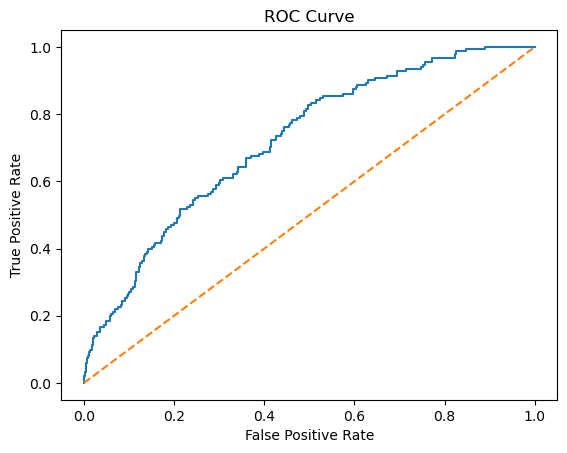

In [73]:
#ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure()
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

In [74]:
#AUC Score
auc = roc_auc_score(y_test, y_prob)
print("AUC Score:", auc)

AUC Score: 0.718946348085421


In [81]:
#Threshold Analysis
#Setting thresholds

thresholds = [0.01, 0.05, 0.1, 0.15, 0.2]
results = []

In [82]:
#Simulation Loop
loan_amount = 20000
interest_rate = 0.28
recovery_rate = 0.4

for t in thresholds:
    approved = y_prob < t
    rejected = y_prob >= t
    
    approved_defaults = y_test[approved].sum()
    approved_loans = approved.sum()
    
    expected_loss = approved_defaults * loan_amount * (1 - recovery_rate)
    
    interest_income = approved_loans * loan_amount * interest_rate
    
    saved_loss = y_test[rejected].sum() * loan_amount * (1 - recovery_rate)
    
    opportunity_cost = (len(y_test[rejected]) - y_test[rejected].sum()) * loan_amount * interest_rate
    
    net_impact = saved_loss + interest_income - opportunity_cost - expected_loss
    
    results.append([t, expected_loss, saved_loss, interest_income, opportunity_cost, net_impact])

print(y_prob[:20])
print("Min:", y_prob.min())
print("Max:", y_prob.max())

[0.12730665 0.06323192 0.01690554 0.04704167 0.02254846 0.06887951
 0.04473774 0.11633927 0.12809566 0.02554983 0.06983379 0.04226692
 0.02610144 0.0239074  0.02909698 0.1434731  0.04485662 0.04196335
 0.09932026 0.04719011]
Min: 0.004464848773069993
Max: 0.22142336745043464


In [83]:
results_df = pd.DataFrame(results, columns=[
    'Threshold', 'Expected Loss', 'Saved Loss',
    'Interest Income', 'Opportunity Cost', 'Net Impact'
])

results_df

,Threshold,Expected Loss,Saved Loss,Interest Income,Opportunity Cost,Net Impact
0,0.01,0.0,1812000.0,459200.0,15495200.0,-13224000.0
1,0.05,588000.0,1224000.0,10046400.0,6182400.0,4500000.0
2,0.10,1308000.0,504000.0,14907200.0,1657600.0,12445600.0
3,0.15,1620000.0,192000.0,16430400.0,280000.0,14722400.0
4,0.20,1776000.0,36000.0,16766400.0,16800.0,15009600.0


In [84]:
#To find optimal threshold
optimal = results_df.loc[results_df['Net Impact'].idxmax()]
optimal

Threshold                  0.2
Expected Loss        1776000.0
Saved Loss             36000.0
Interest Income     16766400.0
Opportunity Cost       16800.0
Net Impact          15009600.0
Name: 4, dtype: float64

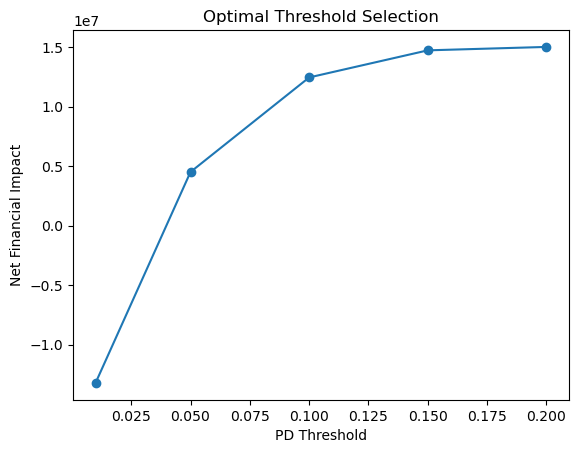

In [85]:
#Visual
plt.figure()
plt.plot(results_df['Threshold'], results_df['Net Impact'], marker='o')
plt.xlabel("PD Threshold")
plt.ylabel("Net Financial Impact")
plt.title("Optimal Threshold Selection")
plt.show()